In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Contoh dataset sederhana
data = pd.DataFrame({
    'luas': [100, 80, 120, 90, 110],
    'kamar': [3, 2, 4, 2, 3],
    'lokasi_score': [9, 6, 8, 5, 7],  # representasi numerik lokasi
    'warna_cat': [1, 0, 2, 1, 0],     # dianggap sebagai fitur numerik dummy
    'harga': [1000, 700, 1300, 800, 1100]
})

In [3]:
data

,luas,kamar,lokasi_score,warna_cat,harga
0,100,3,9,1,1000
1,80,2,6,0,700
2,120,4,8,2,1300
3,90,2,5,1,800
4,110,3,7,0,1100


### ✅ 1. Cara Memilih Fitur Paling Penting di Python

In [4]:
# Pisahkan fitur dan target
X = data.drop('harga', axis=1)
y = data['harga']

In [5]:
# Buat model dan latih
model = RandomForestRegressor()
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Ambil pentingnya fitur
feature_importance = model.feature_importances_

In [7]:
# Tampilkan dalam DataFrame
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Pentingnya': feature_importance
}).sort_values(by='Pentingnya', ascending=False)

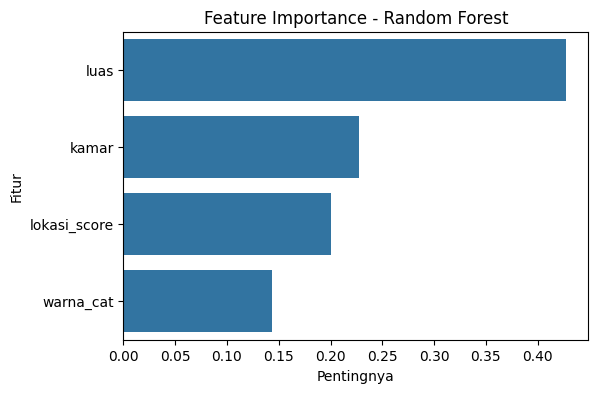

In [8]:
# Visualisasikan
plt.figure(figsize=(6,4))
sns.barplot(x='Pentingnya', y='Fitur', data=importance_df)
plt.title('Feature Importance - Random Forest')
plt.show()

### ✅ 2. Visualisasi Dampak Banyak Fitur

Salah satu cara sederhana untuk melihat dampak fitur terlalu banyak adalah:

Membandingkan performa model saat menggunakan:
- Hanya fitur penting
- Semua fitur (termasuk yang tidak relevan)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [11]:
# Model 1: hanya fitur penting
X1 = data[['luas', 'kamar', 'lokasi_score']]
model1 = LinearRegression()
score1 = cross_val_score(model1, X1, y, cv=3, scoring='neg_mean_squared_error').mean()

In [12]:
# Model 2: semua fitur
X2 = data.drop('harga', axis=1)
model2 = LinearRegression()
score2 = cross_val_score(model2, X2, y, cv=3, scoring='neg_mean_squared_error').mean()

In [13]:
print("Skor MSE (negatif):")
print("Model dengan fitur penting :", score1)
print("Model dengan semua fitur  :", score2)

Skor MSE (negatif):
Model dengan fitur penting : -553.4061038799142
Model dengan semua fitur  : -4766.598214479706


#### 📘 Apa itu MSE (Mean Squared Error)?

MSE adalah metrik evaluasi untuk model regresi yang menghitung rata-rata dari kuadrat selisih antara *nilai prediksi* dan *nilai aktual*

🔸 Semakin kecil nilai MSE, semakin baik prediksi model.

🔸 Nilainya selalu positif, tapi scikit-learn pakai nilai negatif dari MSE untuk keperluan cross_val_score karena by default cross_val_score mencari nilai maksimum, bukan minimum.

Jadi:
- 553.41 → artinya MSE-nya +553.41
- 4766.60 → artinya MSE-nya +4766.60

📊 Interpretasi Hasil:
Model	Neg. MSE Skor	MSE Asli
Model dengan fitur penting	-553.41	✅ 553.41
Model dengan semua fitur	-4766.60	❌ 4766.60

### ✅ 2. RFE (Recursive Feature Elimination)

In [14]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Fitur dan target
X = data[['luas', 'kamar', 'lokasi_score', 'warna_cat']]
y = data['harga']

# Model dasar (misalnya regresi linear)
model = LinearRegression()

In [16]:
# Terapkan RFE untuk memilih 2 fitur terbaik
rfe = RFE(estimator=model, n_features_to_select=3)
rfe.fit(X, y)

# Lihat hasil
selected_features = X.columns[rfe.support_]
print("Fitur terpilih oleh RFE:", selected_features)

Fitur terpilih oleh RFE: Index(['luas', 'kamar', 'lokasi_score'], dtype='object')


### ✅ 1. PCA (Principal Component Analysis)

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [26]:
# Misal fitur numerik
X = data[['luas', 'kamar', 'lokasi_score']]

# Normalisasi sebelum PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Terapkan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [27]:
# Lihat hasil
print("Rasio Variansi Tiap Komponen:", pca.explained_variance_ratio_)

Rasio Variansi Tiap Komponen: [0.84756421 0.14234935]


In [25]:
X_pca

array([[ 0.91276399,  1.10782937, -0.10490264],
       [-1.85791801,  0.38905815,  0.19907678],
       [ 2.18742327, -0.49297192,  0.2087743 ],
       [-1.81947278, -0.57139684, -0.07669155],
       [ 0.57720354, -0.43251875, -0.22625688]])

[0.84756421 0.98991356 1.        ]


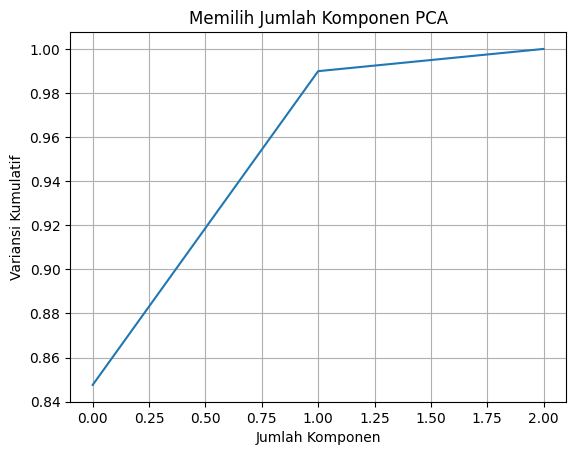

In [23]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variansi kumulatif
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

# Plot untuk bantu memilih
import matplotlib.pyplot as plt
plt.plot(cumulative_variance)
plt.xlabel('Jumlah Komponen')
plt.ylabel('Variansi Kumulatif')
plt.title('Memilih Jumlah Komponen PCA')
plt.grid(True)
plt.show()
